In [18]:
import numpy as np 
import pandas as pd 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score 
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
RANDOM_STATE = 55

## Introduction 

**Dataset** 
* This dataset is obtained from Kaggle: [Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

**Attribute Information** 
* Age
* Sex
* ChestPainType
* RestingBP
* Cholesterol
* FastingBS
* RestingECG
* MaxHR
* ExcerciseAgina
* Oldpeak
* ST_Slope
* HeartDisease

In [10]:
df = pd.read_csv("data/heart.csv") 

In [11]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 2. One-hot encoding using Pandas 
First, we will remove the binary variables, because one-hot encoding them would do nothing to them. To achieve this, we will just count how many different values there are in each categorical variable and consider only the variables with 3 or more values. 

In [4]:
cat_variables = ['Sex',
'ChestPainType',
'RestingECG',
'ExerciseAngina',
'ST_Slope'
]

In [12]:
# This will replace the columns with the one-hot encoded ones and keep the columns outside 'columns' argument as it is.
df = pd.get_dummies(data = df,
                         prefix = cat_variables,
                         columns = cat_variables)

In [13]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [14]:
features = [x for x in df.columns if x not in 'HeartDisease']

In [16]:
print(len(features))

20


In [19]:
x_train, x_val, y_train, y_val = train_test_split(df[features], df['HeartDisease'], train_size = 0.8, random_state = RANDOM_STATE)

In [22]:
print(f'train samples: {len(x_train)}') 
print(f'validation samples: {len(x_val)}') 
print(f'target proportion: {sum(y_train)/len(y_train):.4f}') 

train samples: 734
validation samples: 184
target proportion: 0.5518


## 4.Building the Models
### 4.1 Decision Tree

There are several hyperparameters in the Decision Tree object from Scikit-learn. We will use only some of them and also we will not perform feature selection nor hyperparameter tuning in this lab. 

The hyperparameter we will use and investigate here are: 
* min_samples_split: the mininum number of samples required to split an internal node
  * Choosing a higher min_samples_split can reduce the number of splits and may help to reduce overfitting
* max_depth: the maximum depth of the tree

In [23]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700] ## If the number is an integer, then it is the actual quantity of samples,
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64, None] # None means that there is no depth limit.

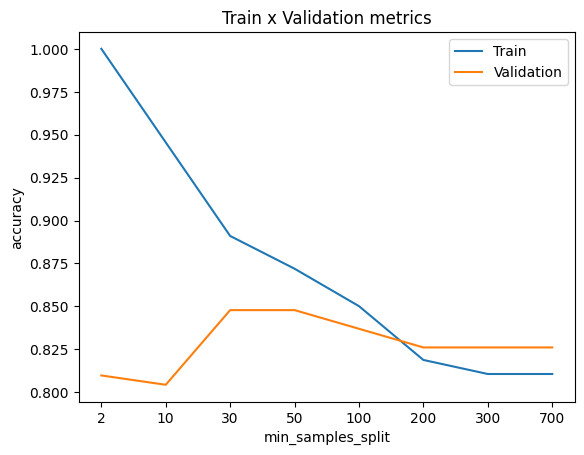

In [24]:
accuracy_list_train = []
accuracy_list_val = []
for min_samples_split in min_samples_split_list: 
    model = DecisionTreeClassifier(min_samples_split = min_samples_split, 
                                    random_state = RANDOM_STATE).fit(x_train, y_train)
    predictions_train = model.predict(x_train) 
    predictions_val = model.predict(x_val) 
    accuracy_train = accuracy_score(predictions_train, y_train) 
    accuracy_val = accuracy_score(predictions_val, y_val) 
    accuracy_list_train.append(accuracy_train) 
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics') 
plt.xlabel('min_samples_split') 
plt.ylabel('accuracy') 
plt.xticks(ticks = range(len(min_samples_split_list)), labels = min_samples_split_list) 
plt.plot(accuracy_list_train) 
plt.plot(accuracy_list_val) 
plt.legend(['Train', 'Validation'])

Note how increasing the number of `min_samples_split` reduces overfitting
* Increasing `min_samples_split` from 10 to 30, and from 30 to 50, even though it does not improve the validation accuracy, it brings the training accuracy closer to it, showing a reduction in overfitting 

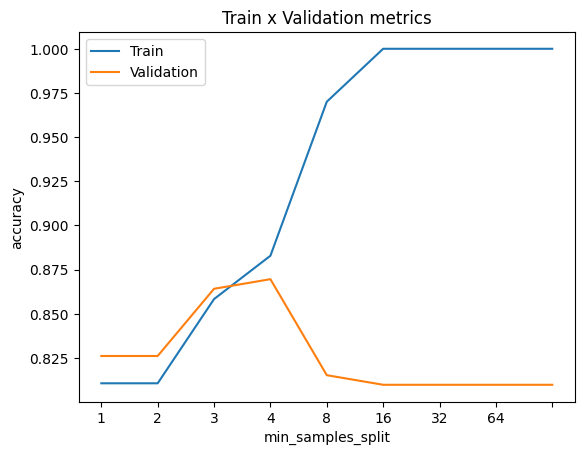

In [25]:
accuracy_list_train = []
accuracy_list_val = []
for max_depth in max_depth_list: 
    model = DecisionTreeClassifier(max_depth = max_depth, 
                                   random_state = RANDOM_STATE).fit(x_train, y_train) 
    predictions_train = model.predict(x_train) 
    predictions_val = model.predict(x_val) 
    accuracy_train = accuracy_score(predictions_train, y_train) 
    accuracy_val = accuracy_score(predictions_val, y_val)
    accuracy_list_train.append(accuracy_train) 
    accuracy_list_val.append(accuracy_val)
plt.title('Train x Validation metrics') 
plt.xlabel('min_samples_split') 
plt.ylabel('accuracy') 
plt.xticks(ticks = range(len(max_depth_list)), labels = max_depth_list) 
plt.plot(accuracy_list_train) 
plt.plot(accuracy_list_val) 
plt.legend(['Train', 'Validation'])

In [27]:
random_forest_model = RandomForestClassifier(n_estimators = 100, 
                                             max_depth = 16, 
                                             min_samples_split = 10).fit(x_train, y_train) 

In [29]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(x_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(x_val),y_val):.4f}")

Metrics train:
	Accuracy score: 0.9292
Metrics test:
	Accuracy score: 0.8859


In [30]:
n = int(len(x_train)*0.8)

In [31]:
x_train_fit, x_train_eval, y_train_fit, y_train_eval = x_train[:n], x_train[n:], y_train[:n], y_train[n:]

In [51]:
xgb_model = XGBClassifier(n_estimators = 500, learning_rate = 0.1, verbosity = 1, random_state = RANDOM_STATE, early_stopping_rounds = 10)

In [45]:
print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [52]:
xgb_model.fit(
    x_train_fit,
    y_train_fit,
    eval_set=[(x_train_eval, y_train_eval)],
)


[0]	validation_0-logloss:0.63301
[1]	validation_0-logloss:0.59553
[2]	validation_0-logloss:0.56612
[3]	validation_0-logloss:0.54186
[4]	validation_0-logloss:0.52348
[5]	validation_0-logloss:0.50610
[6]	validation_0-logloss:0.49371
[7]	validation_0-logloss:0.48365
[8]	validation_0-logloss:0.47321
[9]	validation_0-logloss:0.46537
[10]	validation_0-logloss:0.45999
[11]	validation_0-logloss:0.45620
[12]	validation_0-logloss:0.45482
[13]	validation_0-logloss:0.44974
[14]	validation_0-logloss:0.44494
[15]	validation_0-logloss:0.44072
[16]	validation_0-logloss:0.44078
[17]	validation_0-logloss:0.43935
[18]	validation_0-logloss:0.44206
[19]	validation_0-logloss:0.44536
[20]	validation_0-logloss:0.44321
[21]	validation_0-logloss:0.44310
[22]	validation_0-logloss:0.44419
[23]	validation_0-logloss:0.44797
[24]	validation_0-logloss:0.44843
[25]	validation_0-logloss:0.45337
[26]	validation_0-logloss:0.45206
[27]	validation_0-logloss:0.45435


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [53]:
xgb_model.best_iteration

17

In [56]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(xgb_model.predict(x_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(xgb_model.predict(x_val),y_val):.4f}")

Metrics train:
	Accuracy score: 0.9319
Metrics test:
	Accuracy score: 0.8533
